In [6]:
import numpy as np
import pandas as pd

from src.data.shrinkage.datasets import DATASETS_CLASSIFICATION, DATASETS_REGRESSION
from imodels.util.data_util import get_clean_dataset


metadata = []
columns = ['Name', 'Samples', 'Features']

#for dset_name, dset_file, data_source in DATASETS_REGRESSION:
# Fetch the dataset
dset_name = "TUANDROMD"
data = pd.read_csv("/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/data/high_dimensional/TUANDROMD.csv")
y = data["Label"]  # Extract the target column
X = data.drop(columns=["Label"])  # Drop the target column to get features


try:
    # Attempt to convert y to a numeric array
    y = np.asarray(y, dtype=float)

    # Collect dataset metadata
    shape = X.shape
    metadata.append([
        dset_name.capitalize(),
        shape[0], shape[1]
    ])
except (ValueError, TypeError) as e:
    # Log an error and skip the dataset if y is non-numeric
    print(f"Skipping dataset {dset_name} due to non-numeric target variable. Error: {e}")

# Create and display the metadata DataFrame
metadata = pd.DataFrame(metadata, columns=columns).round(1).sort_values(by=['Samples'], ascending=False)
#print(add_citations(metadata).to_latex(index=False, escape=False).replace('regr', ''))
metadata


,Name,Samples,Features
0,Tuandromd,4465,241


#Predict and then Train the Tuandromd dataset
TUNADROMD dataset contains 4465 instances and 241 attributes. The target attribute for classification is a category (malware vs good ware). (N.B. This is the preprocessed version of TUANDROMD)

Cite : TUNADROMD [Dataset]. (2021). UCI Machine Learning Repository. https://doi.org/ 10.1109/CICT51604.2020.9312053.

In [18]:
from sklearn.metrics import accuracy_score, roc_auc_score
from src.trees import HoeffdingTreeClassifier


# Candidate lambda values for HS predictions
#lambda_list = [0.0, 0.1, 1, 10, 25.0, 50.0, 100.0]
lambda_list = [100.0, 110.0, 120.0, 150.0, 180.0, 200.0]
# Candidate split confidence values to search over
split_confidence_list = [1e-10, 1e-07, 1e-05, 0.001, 0.01, 0.1, 0.5, 0.7, 1]
#lambda_list = [50]

# To store the grid search results for all datasets
grid_search_results = []
tuning_results = []


best_accuracy = -1.0
best_standard_accuracy = -1.0
best_params = {}
best_difference_in_accuracy = -1.0




print("Dataset : " + str(dset_name))
for lam in lambda_list:
    # for each lambda, iterate over each split confidence candidate.
    best_split_conf = 0
    #for sc in split_confidence_list:
        # Initialize a fresh HoeffdingTreeClassifier with the current split confidence.
        #tree = HoeffdingTreeClassifier(split_confidence=sc)
    tree = HoeffdingTreeClassifier(split_confidence=0.1)

    hs_predictions = []
    actual_labels = []
    standard_predictions = []

    # Run a test-then-train simulation over the data stream.
    for i in range(len(X)):
        instance_features = X[i].reshape(1, -1)
        actual_value = y[i]

        # Predict with the HS model using the current lambda.

        standard_pred = tree.predict(instance_features)[0]
        standard_predictions.append(standard_pred)
        hs_pred = tree.predictHS(instance_features, lambda_selected=lam)[0]
        hs_predictions.append(hs_pred)
        actual_labels.append(actual_value)

        # Update the model with the new instance.
        tree.partial_fit(instance_features, [actual_value], classes=np.unique(y))

    # Compute the accuracy of the HS predictions.
    hs_accuracy = accuracy_score(actual_labels, hs_predictions)
    #print(f"  Lambda: {lam}, Split Confidence: {sc} => HS Accuracy: {hs_accuracy:.6f}")

    standard_accuracy = accuracy_score(actual_labels, standard_predictions)
    if lam == 0:
        print(tree.get_model_description())


    print("Lambda : " + str(lam))
    print("Standard HT accuracy : " + str(standard_accuracy))
    print("HT with HS accuracy : " + str(hs_accuracy))


# (Optional) Display a summary of the grid search results across all datasets.
# results_df = pd.DataFrame(grid_search_results)
# print("\nGrid Search Summary:")
# print(results_df)


Dataset : TUANDROMD
Lambda : 100.0
Standard HT accuracy : 0.8098
HT with HS accuracy : 0.8059666666666667
Lambda : 110.0
Standard HT accuracy : 0.8098
HT with HS accuracy : 0.8065666666666667
Lambda : 120.0
Standard HT accuracy : 0.8098
HT with HS accuracy : 0.8065666666666667
Lambda : 150.0
Standard HT accuracy : 0.8098
HT with HS accuracy : 0.8073333333333333
Lambda : 180.0
Standard HT accuracy : 0.8098
HT with HS accuracy : 0.8069333333333333
Lambda : 200.0
Standard HT accuracy : 0.8098
HT with HS accuracy : 0.8066


#Tune on split_confidence and lambda

In [19]:
from sklearn.metrics import accuracy_score, roc_auc_score
from src.trees import HoeffdingTreeClassifier



# Candidate lambda values for HS predictions
lambda_list = [0.0, 0.1, 1, 10, 25.0, 50.0, 100.0]
# Candidate split confidence values to search over
split_confidence_list = [1e-10, 1e-07, 1e-05, 0.001, 0.01, 0.1, 0.5, 0.7, 1]


grid_search_results = []
tuning_results = []


best_accuracy = -1.0
best_standard_accuracy = -1.0
best_params = {}
best_difference_in_accuracy = -1.0


for lam in lambda_list:
    # For each lambda, iterate over each split confidence candidate
    best_split_conf = 0
    for sc in split_confidence_list:
        # Initialize a fresh HoeffdingAdaptiveTreeClassifier with the current split confidence.
        tree = HoeffdingTreeClassifier(split_confidence=sc)
        hs_predictions = []
        actual_labels = []
        standard_predictions = []

        # Run a test-then-train simulation over the data stream.
        for i in range(len(X)):
            instance_features = X[i].reshape(1, -1)
            actual_value = y[i]

            # Predict with the HS model using the current lambda.

            standard_pred = tree.predict(instance_features)[0]
            standard_predictions.append(standard_pred)
            hs_pred = tree.predictHS(instance_features, lambda_selected=lam)[0]
            hs_predictions.append(hs_pred)
            actual_labels.append(actual_value)

            # Update the model with the new instance.
            tree.partial_fit(instance_features, [actual_value], classes=np.unique(y))

        # Compute the accuracy of the HS predictions.
        hs_accuracy = accuracy_score(actual_labels, hs_predictions)
        #print(f"  Lambda: {lam}, Split Confidence: {sc} => HS Accuracy: {hs_accuracy:.6f}")

        standard_accuracy = accuracy_score(actual_labels, standard_predictions)


        # Record the results for this combination.
        grid_search_results.append({
            "Dataset": dset_name,
            "Lambda": lam,
            "Split Confidence": sc,
            "HS Accuracy": hs_accuracy
        })

        # Track the best combination for the current dataset.
        if lam >=0.1 and hs_accuracy - standard_accuracy > best_difference_in_accuracy:
            best_accuracy = hs_accuracy
            best_standard_accuracy = standard_accuracy
            best_params = {"Lambda": lam, "Split Confidence": sc}
            best_difference_in_accuracy = hs_accuracy - standard_accuracy

tuning_results.append({
            "Dataset": dset_name,
            "Lambda": best_params.get(0),
            "Split Confidence": best_params.get(1),
            "Standard Accuracy": best_standard_accuracy,
            "HS Accuracy": best_accuracy
        })
print("Standard HT accuracy : " + str(best_standard_accuracy))
print(f"Best hyperparameters for {dset_name}: {best_params} with HS Accuracy: {best_accuracy:.6f}")


# (Optional) Display a summary of the grid search results across all datasets.
results_df = pd.DataFrame(grid_search_results)
print("\nGrid Search Summary:")
print(results_df)


Standard HT accuracy : 0.8156666666666667
Best hyperparameters for TUANDROMD: {'Lambda': 100.0, 'Split Confidence': 0.001} with HS Accuracy: 0.815700

Grid Search Summary:
      Dataset  Lambda  Split Confidence  HS Accuracy
0   TUANDROMD     0.0      1.000000e-10     0.815200
1   TUANDROMD     0.0      1.000000e-07     0.814967
2   TUANDROMD     0.0      1.000000e-05     0.779800
3   TUANDROMD     0.0      1.000000e-03     0.815667
4   TUANDROMD     0.0      1.000000e-02     0.811133
..        ...     ...               ...          ...
58  TUANDROMD   100.0      1.000000e-02     0.808133
59  TUANDROMD   100.0      1.000000e-01     0.805967
60  TUANDROMD   100.0      5.000000e-01     0.808333
61  TUANDROMD   100.0      7.000000e-01     0.808333
62  TUANDROMD   100.0      1.000000e+00     0.808333

[63 rows x 4 columns]


#Test and Train the Human Activity recognition dataset
Citation : Reyes-Ortiz, J., Anguita, D., Ghio, A., Oneto, L., & Parra, X. (2013). Human Activity Recognition Using Smartphones [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C54S4K.

In [3]:
import pandas as pd
import numpy as np

# Define file paths
train_folder = "/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/data/UCI_HAR_Dataset/train/"
test_folder = "/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/data/UCI_HAR_Dataset/test/"

X_train_path = train_folder + "X_train.txt"
y_train_path = train_folder + "y_train.txt"

X_test_path = test_folder + "X_test.txt"
y_test_path = test_folder + "y_test.txt"

# Read X_train and X_test
X_train = pd.read_csv(X_train_path, delim_whitespace=True, header=None)
X_test = pd.read_csv(X_test_path, delim_whitespace=True, header=None)

# Read y_train and y_test (assuming a single-column format)
y_train = pd.read_csv(y_train_path, delim_whitespace=True, header=None).squeeze("columns")
y_test = pd.read_csv(y_test_path, delim_whitespace=True, header=None).squeeze("columns")

# Get feature names (if available, else create generic feature names)
features = [f"feature_{i}" for i in range(X_train.shape[1])]
X_train.columns = features
X_test.columns = features

# Print shape
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


/var/folders/ys/hswpp7j91yq7v_29s1ksyrfh0000gq/T/ipykernel_71903/2796594442.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv(X_train_path, delim_whitespace=True, header=None)
/var/folders/ys/hswpp7j91yq7v_29s1ksyrfh0000gq/T/ipykernel_71903/2796594442.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv(X_test_path, delim_whitespace=True, header=None)


X_train shape: (7352, 561), y_train shape: (7352,)
X_test shape: (2947, 561), y_test shape: (2947,)


/var/folders/ys/hswpp7j91yq7v_29s1ksyrfh0000gq/T/ipykernel_71903/2796594442.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_train = pd.read_csv(y_train_path, delim_whitespace=True, header=None).squeeze("columns")
/var/folders/ys/hswpp7j91yq7v_29s1ksyrfh0000gq/T/ipykernel_71903/2796594442.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_test = pd.read_csv(y_test_path, delim_whitespace=True, header=None).squeeze("columns")


In [26]:
X_test

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_551,feature_552,feature_553,feature_554,feature_555,feature_556,feature_557,feature_558,feature_559,feature_560
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,0.071645,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.401189,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,0.062891,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,0.116695,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.121711,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,0.074472,-0.376278,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784
2943,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,0.101859,-0.320418,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412
2944,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.066249,-0.118854,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184
2945,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,-0.289477,0.007471,...,-0.046467,-0.205445,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563


# Concatenate the test and train data together so we can perform test then train with streams

In [4]:
# Concatenate X_train and X_test
X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)

# Concatenate y_train and y_test
y = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

# Print the shapes to verify
print(f"Total X shape: {X.shape}")
print(f"Total y shape: {y.shape}")

Total X shape: (10299, 561)
Total y shape: (10299,)


In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from scipy.special import softmax

# ===== STEP 1: ENSURE SAFE DATA TYPES =====
# Convert to float32 to prevent overflow
X = X.astype(np.float32)
y = y.astype(np.float32)  # If y is numeric


X = np.nan_to_num(X, nan=0.0, posinf=1e6, neginf=-1e6)  # Replace NaN with 0, Inf with large values

# ===== STEP 3: CLIP EXTREME VALUES =====
X = np.clip(X, -10, 10)  # Keep values within a reasonable range

# ===== STEP 4: ROBUST SCALING (Outlier-Resistant Normalization) =====
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=[f"feature_{i}" for i in range(X_scaled.shape[1])])

# ===== STEP 5: LOG TRANSFORMATION (For Stability) =====
X = np.log1p(np.abs(X)) * np.sign(X)  # Log-scaling while preserving sign

In [49]:
X.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_551,feature_552,feature_553,feature_554,feature_555,feature_556,feature_557,feature_558,feature_559,feature_560
0,0.374118,-0.219010,-0.630270,-0.089857,-0.180138,-0.106268,-0.086834,-0.176451,-0.131009,-0.083483,...,-0.495750,0.097174,-0.023693,-0.372384,0.046436,-0.387729,-0.018090,-0.366331,-0.010549,-0.230063
1,0.056765,0.061359,-0.475025,-0.094555,-0.171999,-0.173853,-0.093145,-0.167452,-0.179411,-0.094192,...,0.080958,-0.464253,-0.377357,0.173122,-0.031285,-0.515731,0.597748,-0.373556,-0.008803,-0.215246
2,0.107695,-0.169550,-0.209279,-0.090018,-0.163408,-0.198509,-0.089247,-0.154963,-0.205520,-0.088601,...,0.583837,-0.141764,-0.169298,-0.384719,0.276182,0.091850,0.643617,-0.381874,-0.007051,-0.196768
3,0.088499,-0.473378,-0.470245,-0.091148,-0.180440,-0.213459,-0.090237,-0.175982,-0.220529,-0.088601,...,0.572026,0.413753,0.470820,-0.171827,-0.042165,0.459658,-0.473132,-0.381309,-0.000478,-0.191474
4,-0.025584,0.048928,-0.272299,-0.094386,-0.177761,-0.213216,-0.092319,-0.172647,-0.221950,-0.093431,...,-0.165569,-0.045616,0.014529,0.359885,0.201606,0.484204,-0.547630,-0.379745,0.015705,-0.177486


In [29]:
y

0        5
1        5
2        5
3        5
4        5
        ..
10294    2
10295    2
10296    2
10297    2
10298    2
Name: 0, Length: 10299, dtype: int64

In [6]:
dset_name = "Activity recognition with Smartphones"

In [11]:
from sklearn.metrics import accuracy_score, roc_auc_score
from src.trees import HoeffdingTreeClassifier


# Candidate lambda values for HS predictions
lambda_list = [0.0, 1, 10, 25.0, 50.0, 100.0]
#lambda_list = [100.0, 110.0, 120.0, 150.0, 180.0, 200.0]
# Candidate split confidence values to search over
split_confidence_list = [1e-10, 1e-07, 1e-05, 0.001, 0.01, 0.1, 0.5, 0.7, 1]
#lambda_list = [50]

# To store the grid search results for all datasets
grid_search_results = []
tuning_results = []


best_accuracy = -1.0
best_standard_accuracy = -1.0
best_params = {}
best_difference_in_accuracy = -1.0




print("Dataset : " + str(dset_name))
for lam in lambda_list:
    # for each lambda, iterate over each split confidence candidate.
    best_split_conf = 0
    #for sc in split_confidence_list:
        # Initialize a fresh HoeffdingTreeClassifier with the current split confidence.
        #tree = HoeffdingTreeClassifier(split_confidence=sc)
    tree = HoeffdingTreeClassifier(split_confidence=0.1)

    hs_predictions = []
    actual_labels = []
    standard_predictions = []

    # Run a test-then-train simulation over the data stream.
    for i in range(len(X)):
        instance_features = X.iloc[i].values.reshape(1, -1)
        actual_value = y.iloc[i]  # Fix y indexing as well

        # Predict with the HS model using the current lambda
        standard_pred = tree.predict(instance_features)[0]
        standard_predictions.append(standard_pred)
        hs_pred = tree.predictHS(instance_features, lambda_selected=lam)[0]
        hs_predictions.append(hs_pred)
        actual_labels.append(actual_value)

        # Update the model with the new instance
        tree.partial_fit(instance_features, [actual_value], classes=np.unique(y))


    # Compute the accuracy of the HS predictions.
    hs_accuracy = accuracy_score(actual_labels, hs_predictions)
    #print(f"  Lambda: {lam}, Split Confidence: {sc} => HS Accuracy: {hs_accuracy:.6f}")

    standard_accuracy = accuracy_score(actual_labels, standard_predictions)
    if lam == 0:
        print(tree.get_model_description())


    print("Lambda : " + str(lam))
    print("Standard HT accuracy : " + str(standard_accuracy))
    print("HT with HS accuracy : " + str(hs_accuracy))



Dataset : Activity recognition with Smartphones
Lambda : 1
Standard HT accuracy : 0.6771531216622974
HT with HS accuracy : 0.5945237401689485
Lambda : 10
Standard HT accuracy : 0.6771531216622974
HT with HS accuracy : 0.5936498689193126
Lambda : 25.0
Standard HT accuracy : 0.6771531216622974
HT with HS accuracy : 0.5946208369744636
Lambda : 50.0
Standard HT accuracy : 0.6771531216622974
HT with HS accuracy : 0.5964656762792504


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x10e1143d0>>
Traceback (most recent call last):
  File "/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/venv/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

In [18]:
from sklearn.metrics import accuracy_score, roc_auc_score
from src.trees import HoeffdingTreeClassifier



# Candidate lambda values for HS predictions
lambda_list = [1, 10, 25.0, 50.0, 100.0]
# Candidate split confidence values to search over
split_confidence_list = [1e-05, 0.001, 0.01, 0.1, 0.5, 0.7, 1]


grid_search_results = []
tuning_results = []


best_accuracy = -1.0
best_standard_accuracy = -1.0
best_params = {}
best_difference_in_accuracy = -1.0


for lam in lambda_list:
    # For each lambda, iterate over each split confidence candidate
    best_split_conf = 0
    for sc in split_confidence_list:
        print("Split confidence : " + str(sc))
        # Initialize a fresh HoeffdingAdaptiveTreeClassifier with the current split confidence.
        tree = HoeffdingTreeClassifier(split_confidence=sc)
        hs_predictions = []
        actual_labels = []
        standard_predictions = []

        # Run a test-then-train simulation over the data stream.
        for i in range(len(X)):
            instance_features = X.iloc[i].values.reshape(1, -1)
            actual_value = y.iloc[i]  # Fix y indexing as well

            # Predict with the HS model using the current lambda
            standard_pred = tree.predict(instance_features)[0]
            standard_predictions.append(standard_pred)
            hs_pred = tree.predictHS(instance_features, lambda_selected=lam)[0]
            hs_predictions.append(hs_pred)
            actual_labels.append(actual_value)

            # Update the model with the new instance
            tree.partial_fit(instance_features, [actual_value], classes=np.unique(y))

        # Compute the accuracy of the HS predictions.
        hs_accuracy = accuracy_score(actual_labels, hs_predictions)
        #print(f"  Lambda: {lam}, Split Confidence: {sc} => HS Accuracy: {hs_accuracy:.6f}")

        standard_accuracy = accuracy_score(actual_labels, standard_predictions)

        if lam == 1:
            print(tree.get_model_description())

        # Record the results for this combination.
        grid_search_results.append({
            "Dataset": dset_name,
            "Lambda": lam,
            "Split Confidence": sc,
            "HS Accuracy": hs_accuracy
        })

        # Track the best combination for the current dataset.
        if lam >=0.1 and hs_accuracy - standard_accuracy > best_difference_in_accuracy:
            best_accuracy = hs_accuracy
            best_standard_accuracy = standard_accuracy
            best_params = {"Lambda": lam, "Split Confidence": sc}
            best_difference_in_accuracy = hs_accuracy - standard_accuracy

        print("lambda : " + str(lam) + ", so far : ")
        print("Standard HT accuracy : " + str(best_standard_accuracy))
        print(f"Best hyperparameters for {dset_name}: {best_params} with HS Accuracy: {best_accuracy:.6f}")

tuning_results.append({
            "Dataset": dset_name,
            "Lambda": best_params.get(0),
            "Split Confidence": best_params.get(1),
            "Standard Accuracy": best_standard_accuracy,
            "HS Accuracy": best_accuracy
        })
print("Standard HT accuracy : " + str(best_standard_accuracy))
print(f"Best hyperparameters for {dset_name}: {best_params} with HS Accuracy: {best_accuracy:.6f}")


# (Optional) Display a summary of the grid search results across all datasets.
results_df = pd.DataFrame(grid_search_results)
print("\nGrid Search Summary:")
print(results_df)


Split confidence : 1e-05
Leaf = Class 6 | {1: np.float64(1722.0), 2: np.float64(1544.0), 3: np.float64(1406.0), 4: np.float64(1777.0), 5: np.float64(1906.0), 6: np.float64(1944.0)}

lambda : 1, so far : 
Standard HT accuracy : 0.6418098844548015
Best hyperparameters for Activity recognition with Smartphones: {'Lambda': 1, 'Split Confidence': 1e-05} with HS Accuracy: 0.641810
Split confidence : 0.001
if Attribute 86 <= 0.19330395758152008:
  if Attribute 50 <= 0.08799999952316284:
    Leaf = Class 5 | {5: np.float64(158.0)}
  if Attribute 50 > 0.08799999952316284:
    Leaf = Class 6 | {4: np.float64(161.0), 5: np.float64(4.0), 6: np.float64(173.0)}
if Attribute 86 > 0.19330395758152008:
  if Attribute 55 <= 0.5610923767089844:
    Leaf = Class 1 | {1: np.float64(136.0), 2: np.float64(84.0), 3: np.float64(127.0), 5: np.float64(1.0)}
  if Attribute 55 > 0.5610923767089844:
    Leaf = Class 2 | {2: np.float64(55.0)}

lambda : 1, so far : 
Standard HT accuracy : 0.6418098844548015
Best hype

#URL reputation dataset

Citation :
Ma, J., Saul, L., Savage, S., & Voelker, G. (2009). URL Reputation [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5H89Q.

In [2]:
import os
from sklearn.datasets import load_svmlight_files
import numpy as np
from sklearn.model_selection import train_test_split


def load_files(files_to_load, num_of_features, change_range=False):
    root_dir = os.path.dirname(os.path.dirname(os.path.abspath("")))
    data_dir = '/Users/pantia-marinaalchirch/PycharmProjects/ht_library_my_version/src/data/high_dimensional/url_svmlight/'

    files = list(map(lambda x: os.path.join(root_dir, data_dir, x), os.listdir(os.path.join(root_dir, data_dir))[: files_to_load]))


    return_array = load_svmlight_files(files)
    features = []
    labels = []

    for each_value in return_array:
        if type(each_value) != np.ndarray:
            features.extend(each_value[:, :num_of_features].toarray().tolist())
        else:
            labels.extend(each_value.tolist())

    features = np.array(features)
    labels = np.array(labels)

    print(features.shape)
    print(np.unique(labels, return_counts=True))

    if change_range:
        labels = np.array(list(map(lambda x: int(x>0), labels)))
        print(np.unique(labels, return_counts=True))
        labels = labels.reshape((-1, 1))

    trainx, testx, trainy, testy = train_test_split(features, labels, train_size=0.975)

    return trainx, trainy, testx, testy

In [3]:
train_x, train_y, test_x, test_y = load_files(2, 500, False)

(40000, 500)
(array([-1.,  1.]), array([26039, 13961]))


In [4]:
type(train_x)

numpy.ndarray

In [5]:
train_x = train_x[:20000]
train_y = train_y[:20000]

In [6]:
train_x.shape


(20000, 500)

In [7]:
train_y.shape

(20000,)

In [8]:
test_x.shape

(1000, 500)

In [9]:
test_y.shape

(1000,)

#train the model

In [11]:
from sklearn.metrics import accuracy_score, roc_auc_score
from src.trees import HoeffdingTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from imodels import HSTreeClassifier


# Candidate lambda values for HS predictions
#lambda_list = [1, 10, 25.0, 50.0, 100.0]
lambda_list = [1.0]
#lambda_list = [100.0, 110.0, 120.0, 150.0, 180.0, 200.0]
# Candidate split confidence values to search over
split_confidence_list = [1e-10, 1e-07, 1e-05, 0.001, 0.01, 0.1, 0.5, 0.7, 1]
#lambda_list = [50]

# To store the grid search results for all datasets
grid_search_results = []
tuning_results = []


best_accuracy = -1.0
best_standard_accuracy = -1.0
best_params = {}
best_difference_in_accuracy = -1.0


dset_name="URL Reputation"

hs_predictions = []
actual_labels = []
standard_predictions = []
hs_accuracies = []
standard_accuracies = []



hs_accuracies_per_5000_instances= []
standard_accuracies_per_5000_instances = []

train_dt_x = []
train_dt_y = []

dt_accuracies_separate_data = []
hs_dt_accuracies_separate_data = []

dt_accuracies_data_from_1_file = []
hs_dt_accuracies_data_from_1_file = []

print("Dataset : " + str(dset_name))
for lam in lambda_list:
    # for each lambda, iterate over each split confidence candidate.
    best_split_conf = 0
    #for sc in split_confidence_list:
        # Initialize a fresh HoeffdingTreeClassifier with the current split confidence.
        #tree = HoeffdingTreeClassifier(split_confidence=sc)
    tree = HoeffdingTreeClassifier(split_confidence=0.001)

    hs_predictions = []
    actual_labels = []
    standard_predictions = []
    hs_accuracies = []
    standard_accuracies = []



    hs_accuracies_per_5000_instances= []
    standard_accuracies_per_5000_instances = []

    train_dt_x = []
    train_dt_y = []

    dt_accuracies_separate_data = []
    hs_dt_accuracies_separate_data = []

    dt_accuracies_data_from_1_file = []
    hs_dt_accuracies_data_from_1_file = []


    for i in range(len(train_x)+1):
        if i % 5000 == 0 and i!=0 and i!=len(train_x):

            test_x_2 = train_x[i:i+1000]
            test_y_2 = train_y[i:i+1000]
            hs_predictions_2 = []
            actual_labels_2 = []
            standard_predictions_2 = []

            #initialize a DTClassifier
            dt_clf = DecisionTreeClassifier()
            #initialize an HSTreeClassifier
            hs_clf = HSTreeClassifier(estimator_=dt_clf, reg_param=lam)

            #Train with DT, and HS with DT
            train_x_dt_array = np.array(train_dt_x)
            train_y_dt_array = np.array(train_dt_y)
            print("train_dt_x.shape : " + str(train_x_dt_array.shape))
            dt_clf.fit(train_x_dt_array, train_y_dt_array)
            hs_clf.fit(train_x_dt_array, train_y_dt_array)

            #Predict with DT, and HS with DT for data that are in the second file (separate data)
            dt_predictions_separate_data = dt_clf.predict(test_x)
            hs_dt_predictions_separate_data = hs_clf.predict(test_x)

            dt_accuracies_separate_data.append(accuracy_score(test_y, dt_predictions_separate_data))
            hs_dt_accuracies_separate_data.append(accuracy_score(test_y, hs_dt_predictions_separate_data))

            #Predict with DT, and HS with DT for data that are inside in the first file
            print("test_x_2.shape : " + str(test_x_2.shape))
            dt_predictions_data_from_1_file = dt_clf.predict(test_x_2)
            hs_dt_predictions_data_from_1_file = hs_clf.predict(test_x_2)

            dt_accuracies_data_from_1_file.append(accuracy_score(test_y_2, dt_predictions_data_from_1_file))
            hs_dt_accuracies_data_from_1_file.append(accuracy_score(test_y_2, hs_dt_predictions_data_from_1_file))



            for j in range(len(test_x_2)):
                #print(j)
                instance_features_2 = test_x_2[j].reshape(1, -1)
                actual_value_2 = test_y_2[j]
                standard_pred_2 = tree.predict(instance_features_2)[0]
                standard_predictions_2.append(standard_pred_2)
                hs_pred_2 = tree.predictHS(instance_features_2, lambda_selected=lam)[0]
                hs_predictions_2.append(hs_pred_2)
                actual_labels_2.append(actual_value_2)


            hs_accuracies_per_5000_instances.append(accuracy_score(actual_labels_2, hs_predictions_2))
            standard_accuracies_per_5000_instances.append(accuracy_score(actual_labels_2, standard_predictions_2))



        if i==len(train_x):
            #print(i)
            hs_predictions_2 = []
            actual_labels_2 = []
            standard_predictions_2 = []
            for k in range(len(test_x)):

                instance_features_2 = test_x[k].reshape(1, -1)
                actual_value_2 = test_y[k]
                standard_pred_2 = tree.predict(instance_features_2)[0]
                standard_predictions_2.append(standard_pred_2)
                hs_pred_2 = tree.predictHS(instance_features_2, lambda_selected=lam)[0]
                hs_predictions_2.append(hs_pred_2)
                actual_labels_2.append(actual_value_2)

            hs_accuracies_per_5000_instances.append(accuracy_score(actual_labels_2, hs_predictions_2))
            standard_accuracies_per_5000_instances.append(accuracy_score(actual_labels_2, standard_predictions_2))

            #initialize a DTClassifier
            dt_clf = DecisionTreeClassifier()
            #initialize an HSTreeClassifier
            hs_clf = HSTreeClassifier(estimator_=dt_clf, reg_param=lam)

            #Train with DT, and HS with DT
            train_x_dt_array = np.array(train_dt_x)
            train_y_dt_array = np.array(train_dt_y)
            print("train_dt_x.shape : " + str(train_x_dt_array.shape))
            dt_clf.fit(train_x_dt_array, train_y_dt_array)
            hs_clf.fit(train_x_dt_array, train_y_dt_array)

            #Predict with DT, and HS with DT for data that are in the second file (separate data)
            dt_predictions_separate_data = dt_clf.predict(test_x)
            hs_dt_predictions_separate_data = hs_clf.predict(test_x)

            dt_accuracies_separate_data.append(accuracy_score(test_y, dt_predictions_separate_data))
            hs_dt_accuracies_separate_data.append(accuracy_score(test_y, hs_dt_predictions_separate_data))


            dt_predictions_data_from_1_file = dt_clf.predict(test_x_2)
            hs_dt_predictions_data_from_1_file = hs_clf.predict(test_x_2)

            dt_accuracies_data_from_1_file.append(accuracy_score(test_y_2, dt_predictions_data_from_1_file))
            hs_dt_accuracies_data_from_1_file.append(accuracy_score(test_y_2, hs_dt_predictions_data_from_1_file))

        #collect the training instances so you can use them later to train the dt models
        if i != len(train_x):
            train_dt_x.append(train_x[i])
            train_dt_y.append(train_y[i])

            instance_features = train_x[i].reshape(1, -1)
            actual_value = train_y[i]

            standard_pred = tree.predict(instance_features)[0]
            standard_predictions.append(standard_pred)
            hs_pred = tree.predictHS(instance_features, lambda_selected=lam)[0]
            hs_predictions.append(hs_pred)
            actual_labels.append(actual_value)

            #hs_accuracy_1_instance = accuracy_score(actual_value, hs_pred)
            #standard_accuracy_1_instance = accuracy_score(actual_value, standard_pred)

            hs_accuracy_total = accuracy_score(actual_labels, hs_predictions)
            standard_accuracy_total = accuracy_score(actual_labels, standard_predictions)

            hs_accuracies.append(hs_accuracy_total)
            standard_accuracies.append(standard_accuracy_total)
            #print("In instance " + str(i) + ", avg accuracy score is : ")
            #print("Standard HT : " + str(standard_accuracy_total))
            #print("HT with HS : " + str(hs_accuracy_total))


            # Update the model with the new instance.
            tree.partial_fit(instance_features, [actual_value], classes=np.unique(train_y))


    # Compute the accuracy of the HS predictions.
    hs_accuracy = accuracy_score(actual_labels, hs_predictions)
    #print(f"  Lambda: {lam}, Split Confidence: {sc} => HS Accuracy: {hs_accuracy:.6f}")

    standard_accuracy = accuracy_score(actual_labels, standard_predictions)
    #if lam == 0:
    #    print(tree.get_model_description())


    print("Lambda : " + str(lam))
    print("Standard HT accuracy : " + str(standard_accuracy))
    print("HT with HS accuracy : " + str(hs_accuracy))




Dataset : URL Reputation
train_dt_x.shape : (5000, 500)
test_x_2.shape : (1000, 500)
train_dt_x.shape : (10000, 500)
test_x_2.shape : (1000, 500)
train_dt_x.shape : (15000, 500)
test_x_2.shape : (1000, 500)
train_dt_x.shape : (20000, 500)
Lambda : 1.0
Standard HT accuracy : 0.33645
HT with HS accuracy : 0.22255


In [12]:
hs_accuracies

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.02857142857142857,
 0.027777777777777776,
 0.02702702702702703,
 0.02631578947368421,
 0.02564102564102564,
 0.025,
 0.024390243902439025,
 0.023809523809523808,
 0.023255813953488372,
 0.022727272727272728,
 0.022222222222222223,
 0.021739130434782608,
 0.02127659574468085,
 0.020833333333333332,
 0.02040816326530612,
 0.02,
 0.0196078431372549,
 0.019230769230769232,
 0.018867924528301886,
 0.018518518518518517,
 0.01818181818181818,
 0.017857142857142856,
 0.017543859649122806,
 0.034482758620689655,
 0.03389830508474576,
 0.03333333333333333,
 0.04918032786885246,
 0.04838709677419355,
 0.047619047619047616,
 0.046875,
 0.046153846153846156,
 0.045454545454545456,
 0.04477611940298507,
 0.04411764705882353,
 0.057971014492753624,
 0.07142857142857142,
 0.07042253521126761,
 0.08

In [13]:
standard_accuracies

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.02857142857142857,
 0.027777777777777776,
 0.02702702702702703,
 0.02631578947368421,
 0.02564102564102564,
 0.025,
 0.024390243902439025,
 0.023809523809523808,
 0.023255813953488372,
 0.022727272727272728,
 0.022222222222222223,
 0.021739130434782608,
 0.02127659574468085,
 0.020833333333333332,
 0.02040816326530612,
 0.02,
 0.0196078431372549,
 0.019230769230769232,
 0.018867924528301886,
 0.018518518518518517,
 0.01818181818181818,
 0.017857142857142856,
 0.017543859649122806,
 0.034482758620689655,
 0.03389830508474576,
 0.03333333333333333,
 0.04918032786885246,
 0.04838709677419355,
 0.047619047619047616,
 0.046875,
 0.046153846153846156,
 0.045454545454545456,
 0.04477611940298507,
 0.04411764705882353,
 0.057971014492753624,
 0.07142857142857142,
 0.07042253521126761,
 0.08

In [14]:
hs_accuracies_per_5000_instances

[0.248, 0.178, 0.16, 0.192]

In [15]:
standard_accuracies_per_5000_instances

[0.343, 0.353, 0.222, 0.339]

In [16]:
dt_accuracies_data_from_1_file

[0.343, 0.347, 0.336, 0.343]

In [17]:
dt_accuracies_separate_data

[0.336, 0.334, 0.335, 0.335]

In [18]:
hs_dt_accuracies_data_from_1_file

[0.967, 0.984, 0.986, 1.0]

In [19]:
hs_dt_accuracies_separate_data

[0.972, 0.98, 0.986, 0.984]

# Plot

length of ht_plot_accuracies : 20000
num_instances : [ 5000 10000 15000 20000]


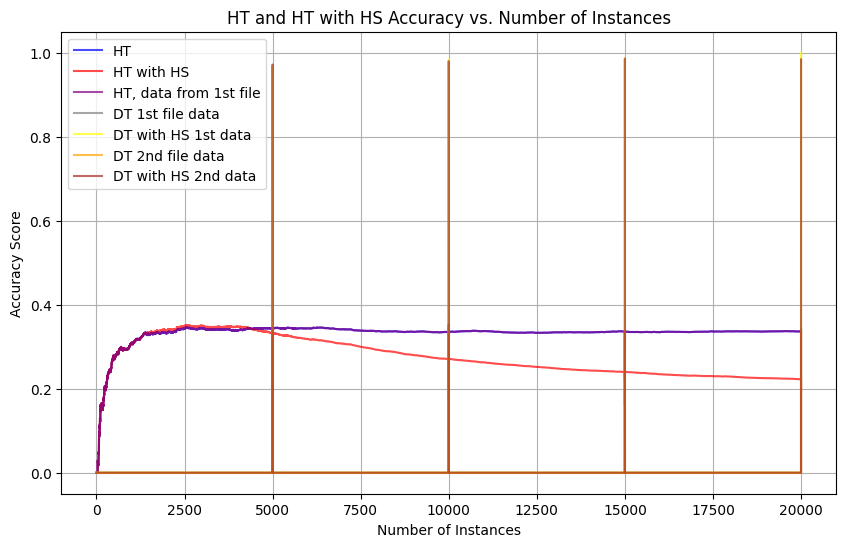

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Define the number of instances based on the given information
num_instances = np.arange(5000, 20001, 5000)  # Since train_x has 20K instances

ht_plot_accuracies = []
hs_ht_plot_accuracies = []
ht_plot_accuracies_1file = []
hs_ht_plot_accuracies_1file = []

dt_plot_accuracies_1file = []
hs_dt_plot_accuracies_1file = []

dt_plot_accuracies_2file = []
hs_dt_plot_accuracies_2file = []

# Fill the accuracy lists using the correct values
for i in range(20000):
    if (i + 1) % 5000 == 0:  # Use per-5000 accuracy at multiples of 5000
        ht_plot_accuracies.append(standard_accuracies_per_5000_instances[(i + 1) // 5000 - 1])
        hs_ht_plot_accuracies.append(hs_accuracies_per_5000_instances[(i + 1) // 5000 - 1])
        ht_plot_accuracies_1file.append(standard_accuracies[(i + 1) // 5000 - 1])
        hs_ht_plot_accuracies_1file.append(hs_accuracies[(i + 1) // 5000 - 1])
        dt_plot_accuracies_1file.append(dt_accuracies_data_from_1_file[(i + 1) // 5000 - 1])
        hs_dt_plot_accuracies_1file.append(hs_dt_accuracies_data_from_1_file[(i + 1) // 5000 - 1])
        dt_plot_accuracies_2file.append(dt_accuracies_separate_data[(i + 1) // 5000 - 1])
        hs_dt_plot_accuracies_2file.append(hs_dt_accuracies_separate_data[(i + 1) // 5000 - 1])

    else:  # Use per-instance running accuracy for all other instances
        ht_plot_accuracies.append(standard_accuracies[i])
        hs_ht_plot_accuracies.append(hs_accuracies[i])

        ht_plot_accuracies_1file.append(standard_accuracies[i])
        hs_ht_plot_accuracies_1file.append(standard_accuracies[i])

        dt_plot_accuracies_1file.append(0)
        hs_dt_plot_accuracies_1file.append(0)
        dt_plot_accuracies_2file.append(0)
        hs_dt_plot_accuracies_2file.append(0)



print("length of ht_plot_accuracies : " + str(len(hs_ht_plot_accuracies)))
print("num_instances : " + str(num_instances))

# Plot accuracy scores for HT and HT with HS
plt.figure(figsize=(10, 6))
num_instances_total = np.linspace(1, 20000, 20000)
plt.plot(num_instances_total, ht_plot_accuracies, label="HT", color="blue", alpha=0.7)
plt.plot(num_instances_total, hs_ht_plot_accuracies, label="HT with HS", color="red", alpha=0.7)
plt.plot(num_instances_total, ht_plot_accuracies_1file, label="HT, data from 1st file", color="purple", alpha=0.7)
#plt.plot(num_instances_total, hs_ht_plot_accuracies_1file, label="HT with HS, data from 1st file", color="green", alpha=0.7)

plt.plot(num_instances_total, dt_plot_accuracies_1file, label="DT 1st file data", color="grey", alpha=0.7)
plt.plot(num_instances_total, hs_dt_plot_accuracies_1file, label="DT with HS 1st data", color="yellow", alpha=0.7)
plt.plot(num_instances_total, dt_plot_accuracies_2file, label="DT 2nd file data", color="orange", alpha=0.7)
plt.plot(num_instances_total, hs_dt_plot_accuracies_2file, label="DT with HS 2nd data", color="brown", alpha=0.7)

# Labels and title
plt.xlabel("Number of Instances")
plt.ylabel("Accuracy Score")
plt.title("HT and HT with HS Accuracy vs. Number of Instances")

# Display legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
